In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [37]:
file_path = r'/home/az1zbekx/MAAB-BI/ml/lesson-2/data/credit_scoring.csv'
df = pd.read_csv(file_path)

In [13]:
df.head()

,children,days_employed,dob_years,education,education_id,family_status,family_status_id,gender,income_type,debt,total_income,purpose
0,1,-8437.673028,42,masters degree,0,married,0,F,employee,0,253875.639453,purchase of the house
1,1,-4024.803754,36,secondary education,1,married,0,F,employee,0,112080.014102,car purchase
2,0,-5623.422610,33,Secondary Education,1,married,0,M,employee,0,145885.952297,purchase of the house
3,3,-4124.747207,32,secondary education,1,married,0,M,employee,0,267628.550329,supplementary education
4,0,340266.072047,53,secondary education,1,civil partnership,1,F,retiree,0,158616.077870,to have a wedding


In [14]:
np.loadtxt(file_path, skiprows=1, delimiter=',', dtype=object)

array([['1', '-8437.673027760233', '42', ..., '0', '253875.6394525987',
        'purchase of the house'],
       ['1', '-4024.803753850451', '36', ..., '0', '112080.01410244203',
        'car purchase'],
       ['0', '-5623.422610230956', '33', ..., '0', '145885.95229686378',
        'purchase of the house'],
       ...,
       ['1', '-2113.3468876977263', '38', ..., '1', '89672.56115303475',
        'property'],
       ['3', '-3112.4817051958507', '38', ..., '1', '244093.0505004255',
        'buying my own car'],
       ['2', '-1984.5075885305268', '40', ..., '0', '82047.41889948228',
        'to buy a car']], shape=(21525, 12), dtype=object)

In [15]:
df.values

array([[1, -8437.673027760233, 42, ..., 0, 253875.6394525987,
        'purchase of the house'],
       [1, -4024.803753850451, 36, ..., 0, 112080.01410244204,
        'car purchase'],
       [0, -5623.422610230956, 33, ..., 0, 145885.95229686378,
        'purchase of the house'],
       ...,
       [1, -2113.3468876977263, 38, ..., 1, 89672.56115303475,
        'property'],
       [3, -3112.4817051958507, 38, ..., 1, 244093.0505004255,
        'buying my own car'],
       [2, -1984.5075885305268, 40, ..., 0, 82047.41889948228,
        'to buy a car']], shape=(21525, 12), dtype=object)

In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 21525 entries, 0 to 21524
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   children          21525 non-null  int64  
 1   days_employed     19351 non-null  float64
 2   dob_years         21525 non-null  int64  
 3   education         21525 non-null  str    
 4   education_id      21525 non-null  int64  
 5   family_status     21525 non-null  str    
 6   family_status_id  21525 non-null  int64  
 7   gender            21525 non-null  str    
 8   income_type       21525 non-null  str    
 9   debt              21525 non-null  int64  
 10  total_income      19351 non-null  float64
 11  purpose           21525 non-null  str    
dtypes: float64(2), int64(5), str(5)
memory usage: 2.0 MB


In [17]:
df.describe()

,children,days_employed,dob_years,education_id,family_status_id,debt,total_income
count,21525.000000,19351.000000,21525.000000,21525.000000,21525.000000,21525.000000,1.935100e+04
mean,0.538908,63046.497661,43.293380,0.817236,0.972544,0.080883,1.674223e+05
std,1.381587,140827.311974,12.574584,0.548138,1.420324,0.272661,1.029716e+05
min,-1.000000,-18388.949901,0.000000,0.000000,0.000000,0.000000,2.066726e+04
25%,0.000000,-2747.423625,33.000000,1.000000,0.000000,0.000000,1.030532e+05
50%,0.000000,-1203.369529,42.000000,1.000000,0.000000,0.000000,1.450179e+05
75%,1.000000,-291.095954,53.000000,1.000000,1.000000,0.000000,2.034351e+05
max,20.000000,401755.400475,75.000000,4.000000,4.000000,1.000000,2.265604e+06


In [26]:
df.isna().sum() / len(df) * 100

children             0.000000
days_employed       10.099884
dob_years            0.000000
education            0.000000
education_id         0.000000
family_status        0.000000
family_status_id     0.000000
gender               0.000000
income_type          0.000000
debt                 0.000000
total_income        10.099884
purpose              0.000000
dtype: float64

In [52]:
df.isna().sum()

children            0
days_employed       0
dob_years           0
education           0
education_id        0
family_status       0
family_status_id    0
gender              0
income_type         0
debt                0
total_income        0
purpose             0
dtype: int64

In [ ]:
m = df['days_employed'].mean()
df['days_employed'] = df['days_employed'].fillna(m)

In [53]:
for column_name in df.select_dtypes(np.number).columns:
    if df[column_name].isna().sum() > 0:
        m = df[column_name].mean()
        df.fillna(m, inplace=True)

In [55]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')

In [61]:
df2 = pd.read_csv(file_path).select_dtypes(np.number).copy()

In [62]:
imputer.fit(df2)

,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'mean'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has nomissing values at fit/train time, the feature won't appear onthe missing indicator even if there are missing values attransform/test time.",False
,"keep_empty_features keep_empty_features: bool, default=FalseIf True, features that consist exclusively of missing values when`fit` is called are returned in results when `transform` is called.The imputed value is always `0` except when `strategy=""constant""`in which case `fill_value` will be used instead... versionadded:: 1.2",False


In [63]:
df2.isna().sum()

children               0
days_employed       2174
dob_years              0
education_id           0
family_status_id       0
debt                   0
total_income        2174
dtype: int64

In [68]:
data = imputer.transform(df2)

In [69]:
type(data)

numpy.ndarray

In [70]:
df2_filled = pd.DataFrame(data = data, columns=df2.columns)

In [71]:
df2_filled.isna().sum()

children            0
days_employed       0
dob_years           0
education_id        0
family_status_id    0
debt                0
total_income        0
dtype: int64

In [97]:
df['children'].describe()

count    21525.000000
mean         0.541092
std          1.379943
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max         20.000000
Name: children, dtype: float64

<Axes: >

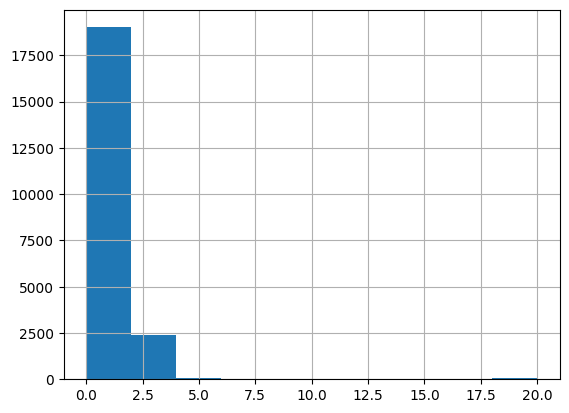

In [96]:
df['children'].hist()

In [100]:
df.loc[df['children'] < 0, 'children'] = 0
df.loc[df['children'] > 3.0, 'children'] = 3

In [102]:
df['children'].describe()

count    21525.000000
mean         0.478328
std          0.753396
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max          3.000000
Name: children, dtype: float64

<Axes: >

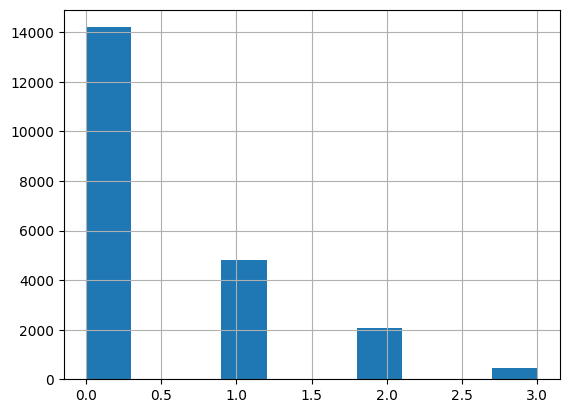

In [104]:
df['children'].hist()

In [108]:
df3 = df.select_dtypes(np.number)

In [116]:
(df3['children'] - df3['children'].mean()) / df3['children'].std()

0        0.692428
1        0.692428
2       -0.634895
3        3.347075
4       -0.634895
           ...   
21520    0.692428
21521   -0.634895
21522    0.692428
21523    3.347075
21524    2.019751
Name: children, Length: 21525, dtype: float64

In [119]:
df3 = (df3 - df3.mean()) / df3.std()

In [120]:
df3

,children,days_employed,dob_years,education_id,family_status_id,debt,total_income
0,0.692428,-0.534858,-0.094335,-1.490930,-0.684734,-0.296642,0.945612
1,0.692428,-0.501784,-0.565845,0.333427,-0.684734,-0.296642,-0.436762
2,-0.634895,-0.513766,-0.801600,0.333427,-0.684734,-0.296642,-0.107186
3,3.347075,-0.502533,-0.880185,0.333427,-0.684734,-0.296642,1.079690
4,-0.634895,2.078642,0.770100,0.333427,0.019331,-0.296642,0.016921
...,...,...,...,...,...,...,...
21520,0.692428,-0.505565,-0.015750,0.333427,0.019331,-0.296642,0.662072
21521,-0.634895,2.106158,1.870290,0.333427,-0.684734,-0.296642,-0.008586
21522,0.692428,-0.487458,-0.408675,0.333427,0.019331,3.370913,-0.655214
21523,3.347075,-0.494946,-0.408675,0.333427,-0.684734,3.370913,0.850241


<Axes: >

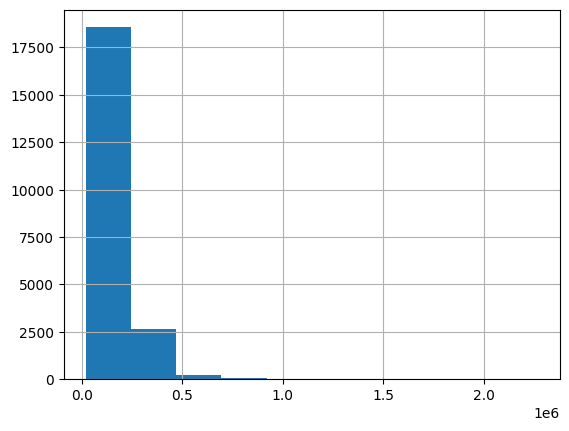

In [125]:
df['total_income'].hist()

<Axes: >

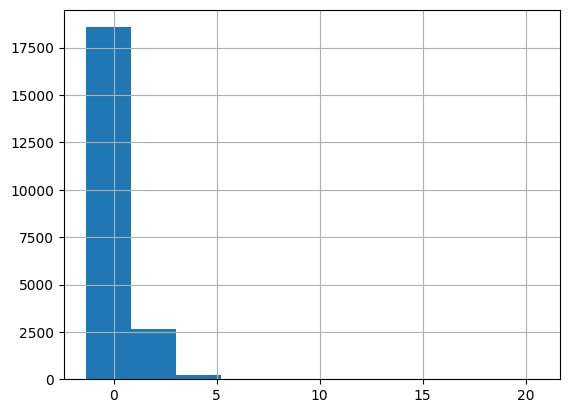

In [126]:
df3['total_income'].hist()

In [130]:
df.isna().sum()

children            0
days_employed       0
dob_years           0
education           0
education_id        0
family_status       0
family_status_id    0
gender              0
income_type         0
debt                0
total_income        0
purpose             0
dtype: int64

In [129]:
df3.isna().sum()

children            0
days_employed       0
dob_years           0
education_id        0
family_status_id    0
debt                0
total_income        0
dtype: int64

In [150]:
df_n = df.select_dtypes(np.number)

In [132]:
arr = df_n.values
arr

array([[ 1.00000000e+00, -8.43767303e+03,  4.20000000e+01, ...,
         0.00000000e+00,  0.00000000e+00,  2.53875639e+05],
       [ 1.00000000e+00, -4.02480375e+03,  3.60000000e+01, ...,
         0.00000000e+00,  0.00000000e+00,  1.12080014e+05],
       [ 0.00000000e+00, -5.62342261e+03,  3.30000000e+01, ...,
         0.00000000e+00,  0.00000000e+00,  1.45885952e+05],
       ...,
       [ 1.00000000e+00, -2.11334689e+03,  3.80000000e+01, ...,
         1.00000000e+00,  1.00000000e+00,  8.96725612e+04],
       [ 3.00000000e+00, -3.11248171e+03,  3.80000000e+01, ...,
         0.00000000e+00,  1.00000000e+00,  2.44093051e+05],
       [ 2.00000000e+00, -1.98450759e+03,  4.00000000e+01, ...,
         0.00000000e+00,  0.00000000e+00,  8.20474189e+04]],
      shape=(21525, 7))

In [133]:
arr.mean()

np.float64(31407.324599497155)

In [134]:
mean_  = np.mean(arr, axis=0)
std__ = np.std(arr, axis=0)

arr_scalled = (arr - mean_) / std__


In [137]:
arr_scalled
arr_scalled.std()
arr_scalled.mean()

np.float64(-1.8957237748502425e-17)

In [139]:
df_n.describe()

,children,days_employed,dob_years,education_id,family_status_id,debt,total_income
count,21525.000000,21525.000000,21525.000000,21525.000000,21525.000000,21525.000000,2.152500e+04
mean,0.478328,62925.255614,43.200418,0.817236,0.972544,0.080883,1.568805e+05
std,0.753396,133424.046362,12.725073,0.548138,1.420324,0.272661,1.025740e+05
min,0.000000,-18388.949901,0.000000,0.000000,0.000000,0.000000,2.066726e+04
25%,0.000000,-2509.982720,33.000000,1.000000,0.000000,0.000000,8.861283e+04
50%,0.000000,-978.027108,42.000000,1.000000,0.000000,0.000000,1.355147e+05
75%,1.000000,63046.497661,53.000000,1.000000,1.000000,0.000000,1.955436e+05
max,3.000000,401755.400475,75.000000,4.000000,4.000000,1.000000,2.265604e+06


In [154]:
from sklearn.preprocessing import StandardScaler

std_scaller = StandardScaler()
std_scaller.fit(df_n)


,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [155]:
data = std_scaller.transform(df_n)
data

array([[ 0.69244412, -0.5348705 , -0.09433706, ..., -0.68474972,
        -0.29664862,  0.94563404],
       [ 0.69244412, -0.50179571, -0.56585806, ..., -0.68474972,
        -0.29664862, -0.4367726 ],
       [-0.63491002, -0.51377748, -0.80161856, ..., -0.68474972,
        -0.29664862, -0.10718871],
       ...,
       [ 0.69244412, -0.4874692 , -0.40868439, ...,  0.01933157,
         3.37099157, -0.65522935],
       [ 3.3471524 , -0.49495779, -0.40868439, ..., -0.68474972,
         3.37099157,  0.85026074],
       [ 2.01979826, -0.48650354, -0.25151073, ..., -0.68474972,
        -0.29664862, -0.72956907]], shape=(21525, 7))

In [156]:
df_n = pd.DataFrame(data, columns=df_n.columns)

In [157]:
df_n

,children,days_employed,dob_years,education_id,family_status_id,debt,total_income
0,0.692444,-0.534870,-0.094337,-1.490965,-0.684750,-0.296649,0.945634
1,0.692444,-0.501796,-0.565858,0.333435,-0.684750,-0.296649,-0.436773
2,-0.634910,-0.513777,-0.801619,0.333435,-0.684750,-0.296649,-0.107189
3,3.347152,-0.502545,-0.880205,0.333435,-0.684750,-0.296649,1.079715
4,-0.634910,2.078690,0.770118,0.333435,0.019332,-0.296649,0.016921
...,...,...,...,...,...,...,...
21520,0.692444,-0.505577,-0.015750,0.333435,0.019332,-0.296649,0.662088
21521,-0.634910,2.106207,1.870334,0.333435,-0.684750,-0.296649,-0.008586
21522,0.692444,-0.487469,-0.408684,0.333435,0.019332,3.370992,-0.655229
21523,3.347152,-0.494958,-0.408684,0.333435,-0.684750,3.370992,0.850261


In [158]:
df_n.describe()

,children,days_employed,dob_years,education_id,family_status_id,debt,total_income
count,2.152500e+04,2.152500e+04,2.152500e+04,2.152500e+04,2.152500e+04,2.152500e+04,2.152500e+04
mean,9.242832e-18,2.806674e-12,1.092635e-16,-1.201568e-16,-6.569013e-17,-3.433052e-17,5.768733e-12
std,1.000023e+00,1.000023e+00,1.000023e+00,1.000023e+00,1.000023e+00,1.000023e+00,1.000023e+00
min,-6.349100e-01,-6.094561e-01,-3.394984e+00,-1.490965e+00,-6.847497e-01,-2.966486e-01,-1.327982e+00
25%,-6.349100e-01,-4.904420e-01,-8.016186e-01,3.334350e-01,-6.847497e-01,-2.966486e-01,-6.655609e-01
50%,-6.349100e-01,-4.789599e-01,-9.433706e-02,3.334350e-01,-6.847497e-01,-2.966486e-01,-2.083009e-01
75%,6.924441e-01,9.087182e-04,7.701181e-01,3.334350e-01,1.933157e-02,-2.966486e-01,3.769383e-01
max,3.347152e+00,2.539557e+00,2.499028e+00,5.806634e+00,2.131575e+00,3.370992e+00,2.055856e+01
